In [44]:
# === Stage E: Multi-horizon, per-basin models (Exogenous only, with baselines) ===
# Inputs (per H): data/modeling/datasets/train_basin_daily_exogenous_h{H}.parquet
# Outputs:
#   - data/modeling/reports/stageE_predictions_multiH_perbasin.parquet
#   - data/modeling/reports/stageE_metrics_multiH_perbasin.csv

In [68]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [46]:
# === Resolve Project Root ===

def get_project_root(max_up=6):
    try:
        root = subprocess.check_output(["git","rev-parse","--show-toplevel"], text=True).strip()
        if root:
            return Path(root)
    except Exception:
        pass
    p = Path.cwd()
    for _ in range(max_up):
        if (p/"data").exists() and (p/"code").exists():
            return p
        if (p/".git").exists():
            return p
        p = p.parent
    return Path.cwd()

PROJECT_ROOT = get_project_root()
print("Project root:", PROJECT_ROOT)


Project root: /Users/qingfangliu/bhutan_climate_modeling


In [47]:
# ---- knobs ----
HORIZONS = [0, 1, 2, 3, 5, 7]
RANDOM_STATE = 42

DATASETS_DIR = PROJECT_ROOT / "data" / "modeling" / "datasets"
REPORTS_DIR = PROJECT_ROOT / "data" / "modeling" / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

all_preds = []   # collect tidy predictions across H and basins
all_metrics = [] # collect tidy metrics across H, basins, and models

In [48]:
def to_bool_series(s: pd.Series) -> pd.Series:
    """Robust bool coercion (returns pandas Boolean dtype)."""
    if s.dtype == bool:
        return s.astype("boolean")
    truthy = {"true","t","yes","y","1",1,True}
    falsy  = {"false","f","no","n","0",0,False}
    def _cast(v):
        if pd.isna(v):
            return pd.NA
        v2 = str(v).strip().lower()
        if v2 in truthy: return True
        if v2 in falsy:  return False
        return pd.NA
    return s.map(_cast).astype("boolean")

In [49]:
# --- Add chronological train/val/test splits per basin ---
def add_time_splits(
    df: pd.DataFrame,
    id_col: str = "basin_id",
    date_col: str = "date_local",
    rule=(0.70, 0.15, 0.15),
) -> pd.DataFrame:
    """
    Label each row with 'train'/'val'/'test' per basin using chronological splits.
    Splits are based on the sorted UNIQUE dates within each basin.
    """
    out = df.copy()
    out["split"] = pd.NA

    for b, g in out.sort_values([id_col, date_col]).groupby(id_col, sort=False):
        dates = np.array(sorted(g[date_col].dropna().unique()))
        n = len(dates)
        if n < 10:
            out.loc[g.index, "split"] = "train"
            continue

        # compute cut sizes (ensure at least 1 test day)
        n_train = int(np.floor(rule[0] * n))
        n_val   = int(np.floor(rule[1] * n))
        if n_train < 1: n_train = 1
        if n_val   < 1: n_val = 1
        if n_train + n_val >= n:  # leave at least 1 for test
            n_val = max(1, n - n_train - 1)
        n_test  = n - n_train - n_val
        if n_test < 1:
            n_test = 1
            if n_val > 1:
                n_val -= 1

        cut_train = dates[n_train - 1]
        cut_val   = dates[n_train + n_val - 1]

        idx = g.index
        d   = out.loc[idx, date_col]
        out.loc[idx, "split"] = np.where(
            d <= cut_train, "train",
            np.where(d <= cut_val, "val", "test")
        )

    return out

In [50]:
# --- Build design matrices per basin (train-median impute; no one-hot) ---

def build_design_matrices_per_basin(df: pd.DataFrame,
                                    feature_cols: list,
                                    id_col: str = "basin_id",
                                    y_col: str = "discharge_cms",
                                    date_col: str = "date_local"):
    """
    Returns:
      dict[basin_id] -> (Xtr, ytr, Xva, yva, Xte, yte, feature_names)
    - Imputes feature NaNs with TRAIN medians (per basin).
    - Drops features that are all-NaN in the TRAIN split for that basin.
    """
    out = {}
    df = df.sort_values([id_col, date_col]).copy()

    for b, g in df.groupby(id_col, sort=False):
        tr = g[g["split"] == "train"]
        va = g[g["split"] == "val"]
        te = g[g["split"] == "test"]

        # Drop features that are entirely NaN in TRAIN for this basin
        allna_in_train = tr[feature_cols].isna().all()
        keep_cols = [c for c in feature_cols if not allna_in_train[c]]
        if len(keep_cols) == 0:
            raise ValueError(f"No usable features for basin {b} (all NaN in train).")

        # Train medians for imputation (per basin)
        med = tr[keep_cols].median()

        Xtr = tr[keep_cols].fillna(med).to_numpy(dtype=float)
        Xva = va[keep_cols].fillna(med).to_numpy(dtype=float)
        Xte = te[keep_cols].fillna(med).to_numpy(dtype=float)
        ytr = tr[y_col].to_numpy()
        yva = va[y_col].to_numpy()
        yte = te[y_col].to_numpy()

        # Safety checks
        if any(np.isnan(X).any() for X in (Xtr, Xva, Xte)):
            raise ValueError(f"NaNs remain in features for basin {b}")
        if any(np.isnan(y).any() for y in (ytr, yva, yte)):
            raise ValueError(f"NaNs found in target for basin {b}")
        assert len(ytr)==len(Xtr) and len(yva)==len(Xva) and len(yte)==len(Xte), \
            f"X/y length mismatch in basin {b}"

        out[int(b) if pd.notna(b) else b] = (Xtr, ytr, Xva, yva, Xte, yte, keep_cols)
        print(f"[Basin {b}] kept {len(keep_cols)} features | shapes Xtr{Xtr.shape}, Xva{Xva.shape}, Xte{Xte.shape}")

    return out


In [51]:
# Filter to pairs where both y and yhat are non-NaN (returns aligned arrays)
def _valid_pairs(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    m = ~(np.isnan(y) | np.isnan(yhat))
    return y[m], yhat[m]

# Mean Absolute Error (ignoring NaN pairs)
def mae(y, yhat):
    y, yhat = _valid_pairs(y, yhat)
    return np.mean(np.abs(y - yhat))

# Root Mean Squared Error (ignoring NaN pairs)
def rmse(y, yhat):
    y, yhat = _valid_pairs(y, yhat)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

# Coefficient of determination R^2 (NaN if y is constant)
def r2(y, yhat):
    y, yhat = _valid_pairs(y, yhat)
    if y.size == 0:
        return np.nan
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Nash–Sutcliffe Efficiency (equivalent to R^2 with mean benchmark)
def nse(y, yhat):
    return r2(y, yhat)

# Kling–Gupta Efficiency (2009): combines correlation, variability, and bias ratios
def kge(y, yhat):
    y, yhat = _valid_pairs(y, yhat)
    if y.size == 0:
        return np.nan
    r = np.corrcoef(y, yhat)[0, 1] if np.std(y) > 0 and np.std(yhat) > 0 else np.nan
    alpha = np.std(yhat) / np.std(y) if np.std(y) > 0 else np.nan
    beta = np.mean(yhat) / np.mean(y) if np.mean(y) != 0 else np.nan
    if any(map(np.isnan, [r, alpha, beta])):
        return np.nan
    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

# Package metrics (plus metadata) into a single dict, counting valid pairs
def metric_row(y, yhat, extra: dict):
    return dict(
        **extra,
        n=len(_valid_pairs(y, yhat)[0]),
        mae=mae(y, yhat),
        rmse=rmse(y, yhat),
        r2=r2(y, yhat),
        nse=nse(y, yhat),
        kge=kge(y, yhat),
    )

In [52]:
# --- Step 5.2: Baseline predictors ---

def fit_climatology(train_df: pd.DataFrame) -> dict:
    """
    Per-basin day-of-year median discharge.
    Fallbacks:
      - basin-wide median (train)
      - global median (train)
    Returns a dict with three Series/DataFrames to use in prediction.
    """
    tr = train_df.copy()
    tr["doy"] = tr["date_local"].dt.dayofyear.clip(upper=365)  # map 366 -> 365
    # per-basin-day median
    med_basin_doy = (tr.groupby(["basin_id", "doy"])["discharge_cms"]
                       .median().rename("q_med"))
    # per-basin overall median
    med_basin = tr.groupby("basin_id")["discharge_cms"].median().rename("q_med_basin")
    # global median
    med_global = float(tr["discharge_cms"].median())
    return {"by_basin_doy": med_basin_doy, "by_basin": med_basin, "global": med_global}

def predict_climatology(df_part: pd.DataFrame, model: dict) -> np.ndarray:
    part = df_part.copy()
    part["doy"] = part["date_local"].dt.dayofyear.clip(upper=365)

    # join basin-doy median
    key = ["basin_id", "doy"]
    pred = part.merge(model["by_basin_doy"].reset_index(), on=key, how="left")["q_med"]

    # fallback to basin median
    miss = pred.isna()
    if miss.any():
        pred.loc[miss] = part.loc[miss].merge(
            model["by_basin"].reset_index(), on="basin_id", how="left"
        )["q_med_basin"].values

    # fallback to global median
    pred.fillna(model["global"], inplace=True)
    return pred.to_numpy(dtype=float)

def predict_persistence(df_full: pd.DataFrame, df_part_idx: pd.Index) -> np.ndarray:
    """
    Persistence: y_hat(t) = y(t-1), computed within each basin on the full split table
    so the first VAL day can use the last TRAIN day (realistic at inference).
    """
    srt = df_full.sort_values(["basin_id", "date_local"]).copy()
    srt["y_pers"] = srt.groupby("basin_id")["discharge_cms"].shift(1)
    # pull back to the requested rows (VAL/TEST)
    return srt.loc[df_part_idx, "y_pers"].to_numpy(dtype=float)


In [53]:
# --- Step 5.3 (patched): Evaluate baselines per-basin + overall ---

def metrics_for_split(df_part: pd.DataFrame, yhat: np.ndarray,
                      track_name: str, baseline_name: str, split_label: str):
    """
    Build metric rows for each basin and an overall row, using df_part masks
    (avoids grouping mistakes on the Series).
    """
    rows = []
    assert len(df_part) == len(yhat), "Prediction length mismatch."

    # Per-basin rows
    for b in sorted(pd.to_numeric(df_part["basin_id"], errors="coerce").dropna().astype(int).unique()):
        msk = (df_part["basin_id"] == b)
        y_true_b = df_part.loc[msk, "discharge_cms"].values
        y_hat_b  = yhat[msk]
        rows.append(
            metric_row(
                y_true_b, y_hat_b,
                dict(track=track_name, model="baseline", baseline=baseline_name,
                     split=split_label, basin_id=int(b))
            )
        )

    # Overall row
    rows.append(
        metric_row(
            df_part["discharge_cms"].values, yhat,
            dict(track=track_name, model="baseline", baseline=baseline_name,
                 split=split_label, basin_id="ALL")
        )
    )
    return rows

def eval_baselines(df_split: pd.DataFrame, track_name="exogenous"):
    rows = []

    # Partitions
    train = df_split[df_split["split"] == "train"].copy()
    val   = df_split[df_split["split"] == "val"].copy()
    test  = df_split[df_split["split"] == "test"].copy()

    # Fit climatology on TRAIN
    clim = fit_climatology(train)

    # Climatology predictions
    yhat_val_clim  = predict_climatology(val,  clim)
    yhat_test_clim = predict_climatology(test, clim)

    # Persistence predictions (use full DF to allow train->val boundary lag)
    yhat_val_pers  = predict_persistence(df_split, val.index)
    yhat_test_pers = predict_persistence(df_split, test.index)

    # Collect metric rows
    rows += metrics_for_split(val,  yhat_val_clim,  track_name, "climatology", "val")
    rows += metrics_for_split(test, yhat_test_clim, track_name, "climatology", "test")
    rows += metrics_for_split(val,  yhat_val_pers,  track_name, "persistence", "val")
    rows += metrics_for_split(test, yhat_test_pers, track_name, "persistence", "test")

    metrics_df = pd.DataFrame(rows)[["track","model","baseline","split","basin_id","n","mae","rmse","r2","nse","kge"]]

    # Also return predictions if you want to plot later
    preds = {
        "val":  pd.DataFrame({"basin_id": val["basin_id"].values,
                              "date_local": val["date_local"].values,
                              "y_true": val["discharge_cms"].values,
                              "yhat_clim": yhat_val_clim,
                              "yhat_pers": yhat_val_pers}),
        "test": pd.DataFrame({"basin_id": test["basin_id"].values,
                              "date_local": test["date_local"].values,
                              "y_true": test["discharge_cms"].values,
                              "yhat_clim": yhat_test_clim,
                              "yhat_pers": yhat_test_pers}),
    }
    return metrics_df, preds

In [54]:


# --- ridge with log1p target; picks best alpha on VAL ---
def train_ridge_log1p(Xtr, ytr, Xva, yva, alphas=(0.1, 1, 3, 10, 30, 100, 300, 1000)):
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xtr_s = scaler.fit_transform(Xtr)
    Xva_s = scaler.transform(Xva)

    ytr_log = np.log1p(np.clip(ytr, 0, None))
    scores, best = [], None
    for a in alphas:
        mdl = Ridge(alpha=float(a))
        mdl.fit(Xtr_s, ytr_log)
        yva_hat = np.expm1(mdl.predict(Xva_s))
        yva_hat = np.clip(yva_hat, 0, None)
        score = nse(yva, yva_hat)   # or r2(yva, yva_hat)
        scores.append((a, score))
        if (best is None) or (score > best[1]):
            best = (a, score, mdl)

    return {
        "alpha": best[0],
        "val_score": best[1],
        "model": best[2],
        "scaler": scaler,
        "scores": pd.DataFrame(scores, columns=["alpha","val_score"]).sort_values("alpha"),
    }

# --- train/evaluate per basin using per_basin_data ---
def run_ridge_per_basin(per_basin_data, track_name="exogenous"):
    rows, results = [], {}
    for b, (Xtr, ytr, Xva, yva, Xte, yte, names) in per_basin_data.items():
        out = train_ridge_log1p(Xtr, ytr, Xva, yva)
        mdl, scaler = out["model"], out["scaler"]

        # predictions (invert log1p and clip at 0)
        yva_hat = np.clip(np.expm1(mdl.predict(scaler.transform(Xva))), 0, None)
        yte_hat = np.clip(np.expm1(mdl.predict(scaler.transform(Xte))), 0, None)

        # metrics
        rows.append(metric_row(yva, yva_hat, dict(track=track_name, model="ridge_log1p", baseline="NA", split="val",  basin_id=b)))
        rows.append(metric_row(yte, yte_hat, dict(track=track_name, model="ridge_log1p", baseline="NA", split="test", basin_id=b)))

        results[b] = {**out, "yva_hat": yva_hat, "yte_hat": yte_hat, "feature_names": names}

        print(f"[Basin {b}] best alpha={out['alpha']} | VAL {out['val_score']:.4f}")

    metrics_df = pd.DataFrame(rows)[["track","model","split","basin_id","n","mae","rmse","r2","nse","kge"]]
    return metrics_df, results

In [57]:
# --- Step 7.1: Choose tree backend (lgbm -> xgb -> rf) ---

TREE_BACKEND = None
try:
    import lightgbm as lgb
    TREE_BACKEND = "lgbm"
    print("Using LightGBM.")
except Exception:
    try:
        import xgboost as xgb
        TREE_BACKEND = "xgb"
        print("LightGBM not available; using XGBoost.")
    except Exception:
        from sklearn.ensemble import RandomForestRegressor
        TREE_BACKEND = "rf"
        print("LightGBM/XGBoost not available; using RandomForest as fallback.")


/Users/qingfangliu/opt/anaconda3/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


Using LightGBM.


In [58]:
def train_tree_log1p(
    Xtr, ytr, Xva, yva,
    backend=TREE_BACKEND,
    random_state=42
):
    ytr_log = np.log1p(np.clip(ytr, 0, None))
    yva_true = yva.astype(float)

    candidates = []  # (name, model, val_nse)

    if backend == "lgbm":
        # small grid; early stopping on VAL
        grids = [
            dict(num_leaves=31, learning_rate=0.1, n_estimators=800),
            dict(num_leaves=31, learning_rate=0.05, n_estimators=1200),
            dict(num_leaves=15, learning_rate=0.1, n_estimators=800),
        ]
        for i, p in enumerate(grids):
            mdl = lgb.LGBMRegressor(
                num_leaves=p["num_leaves"],
                learning_rate=p["learning_rate"],
                n_estimators=p["n_estimators"],
                subsample=0.9, colsample_bytree=0.9,
                reg_alpha=0.0, reg_lambda=0.0,
                random_state=random_state, n_jobs=-1
            )
            mdl.fit(
                Xtr, ytr_log,
                eval_set=[(Xva, ytr_log[:len(Xva)])],  # we just need callbacks; metric on log target
                eval_metric="l2",
                callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)],
            )
            yva_hat = np.expm1(mdl.predict(Xva, num_iteration=mdl.best_iteration_))
            yva_hat = np.clip(yva_hat, 0, None)
            candidates.append((f"lgbm_{i}", mdl, nse(yva_true, yva_hat)))

    elif backend == "xgb":
        grids = [
            dict(max_depth=6, learning_rate=0.1, n_estimators=600),
            dict(max_depth=5, learning_rate=0.05, n_estimators=1000),
        ]
        for i, p in enumerate(grids):
            mdl = xgb.XGBRegressor(
                max_depth=p["max_depth"], learning_rate=p["learning_rate"],
                n_estimators=p["n_estimators"], subsample=0.9, colsample_bytree=0.9,
                objective="reg:squarederror", reg_alpha=0.0, reg_lambda=0.0,
                random_state=random_state, n_jobs=-1
            )
            mdl.fit(
                Xtr, ytr_log,
                eval_set=[(Xva, ytr_log[:len(Xva)])],
                verbose=False
            )
            yva_hat = np.expm1(mdl.predict(Xva))
            yva_hat = np.clip(yva_hat, 0, None)
            candidates.append((f"xgb_{i}", mdl, nse(yva_true, yva_hat)))

    else:  # rf fallback
        from sklearn.ensemble import RandomForestRegressor
        grids = [
            dict(n_estimators=600, max_depth=None),
            dict(n_estimators=600, max_depth=14),
        ]
        for i, p in enumerate(grids):
            mdl = RandomForestRegressor(
                n_estimators=p["n_estimators"], max_depth=p["max_depth"],
                random_state=random_state, n_jobs=-1
            )
            mdl.fit(Xtr, ytr_log)
            yva_hat = np.expm1(mdl.predict(Xva))
            yva_hat = np.clip(yva_hat, 0, None)
            candidates.append((f"rf_{i}", mdl, nse(yva_true, yva_hat)))

    # pick best
    best = max(candidates, key=lambda t: (t[2] if not np.isnan(t[2]) else -np.inf))
    return {"name": best[0], "model": best[1], "val_nse": best[2], "backend": backend}

In [59]:
def predict_with_tree(tree_pack, X):
    """Use trained tree model in tree_pack to predict (log1p target inverted)."""
    yhat = tree_pack["model"].predict(X)
    if yhat.ndim > 1:  # Some libs return 2D
        yhat = yhat.ravel()
    return np.clip(np.expm1(yhat), 0, None)

In [66]:
all_metrics = []  # collect metrics_all for each H here

for H in HORIZONS:
    print('Working on H =',H)
    in_path = DATASETS_DIR / f"train_basin_daily_exogenous_h{H}.parquet"
    df = pd.read_parquet(in_path)
    if "date_local" in df.columns:
        df["date_local"] = pd.to_datetime(df["date_local"], errors="coerce")
    df = df.sort_values(["basin_id", "date_local"]).reset_index(drop=True)

    # feature selection: drop non-features & engineered lags/rollups/APIs (keep it exogenous & simple)
    drop_cols = {"basin_id", "basin_name", "date_local", "discharge_cms", f"y_h{H}", "qc_any"}
    num_candidates = [
        c for c in df.columns
        if c not in drop_cols
        and ("_sum_" not in c)
        and ("_mean_" not in c)
        and ("api_d" not in c)
        and (not c.startswith("q_lag_"))
        and (not c.startswith("q_mean_"))
        and (not c.startswith("q_std_"))
    ]
    
    # Work on a copy of the exogenous dataset first
    work = df.copy()
    
    # Coerce qc_any -> boolean (create if absent, default False = keep)
    if "qc_any" in work.columns:
        work["qc_any"] = to_bool_series(work["qc_any"])
    else:
        work["qc_any"] = pd.Series(False, index=work.index, dtype="boolean")

    # Ensure basin_id is integer-like
    work["basin_id"] = pd.to_numeric(work["basin_id"], errors="coerce").astype("Int64")

    # Policy: keep rows with qc_any == False AND non-null discharge
    mask_keep = (work["qc_any"] == False) & (work["discharge_cms"].notna())
    kept_rows = mask_keep.sum()
    print(f"Rows kept after policy: {kept_rows} / {len(work)} ({kept_rows/len(work):.1%})")
    exog_clean = work.loc[mask_keep].copy()
    
    # Identify constant columns (only 1 unique value)
    const_cols = exog_clean[num_candidates].nunique(dropna=True)
    const_cols = const_cols[const_cols <= 1].index.tolist()
    
    # Update dataset to remove them
    exog_clean = exog_clean.drop(columns=const_cols)
    
    exog_split = add_time_splits(exog_clean, id_col="basin_id", date_col="date_local", rule=(0.70,0.15,0.15))
    
    # Automatically select only numeric columns
    numeric_cols = exog_split.select_dtypes(include=["number"]).columns
    feature_cols = [c for c in numeric_cols if c not in ["basin_id", "discharge_cms"]]
    
    per_basin_data = build_design_matrices_per_basin(exog_split, feature_cols)
    
    baseline_metrics_exog, baseline_preds_exog = eval_baselines(exog_split, track_name="exogenous")
    display(baseline_metrics_exog.sort_values(["split","basin_id","baseline"]))
    
    ridge_metrics_pb, ridge_results_pb = run_ridge_per_basin(per_basin_data, track_name="exogenous")
    display(ridge_metrics_pb.sort_values(["split","basin_id"]))
    all_tree_metrics = []
    
    for b, (Xtr, ytr, Xva, yva, Xte, yte, names) in per_basin_data.items():
        tree_pack = train_tree_log1p(Xtr, ytr, Xva, yva, backend=TREE_BACKEND)
        yva_hat = predict_with_tree(tree_pack, Xva)
        yte_hat = predict_with_tree(tree_pack, Xte)
        all_tree_metrics.append(
            metric_row(yva, yva_hat,
                dict(track="exogenous", model=f"{tree_pack['backend']}_log1p",
                     split="val", basin_id=b))
        )
        all_tree_metrics.append(
            metric_row(yte, yte_hat,
                dict(track="exogenous", model=f"{tree_pack['backend']}_log1p",
                     split="test", basin_id=b))
        )
        print(f"[Basin {b}] {tree_pack['backend']} chosen={tree_pack['name']} | VAL NSE={tree_pack['val_nse']:.3f}")

    tree_metrics_df = pd.DataFrame(all_tree_metrics)[["track","model","split","basin_id","n","mae","rmse","r2","nse","kge"]]
    display(tree_metrics_df.sort_values(["split","basin_id"]))
    
    bm = baseline_metrics_exog.assign(model_key="baseline:" + baseline_metrics_exog["baseline"])
    rm = ridge_metrics_pb.assign(model_key="ridge_log1p")
    tm = tree_metrics_df.assign(model_key=f"{TREE_BACKEND}_log1p")

    metrics_all = (pd.concat([bm, rm, tm], ignore_index=True)
                     .sort_values(["split", "basin_id", "model_key"])
                     .reset_index(drop=True))
    metrics_all["horizon"] = H
    
    all_metrics.append(metrics_all)

    

Working on H = 0
Rows kept after policy: 29143 / 29185 (99.9%)
[Basin 3] kept 132 features | shapes Xtr(6008, 132), Xva(1287, 132), Xte(1289, 132)
[Basin 6] kept 132 features | shapes Xtr(8374, 132), Xva(1794, 132), Xte(1796, 132)
[Basin 8] kept 132 features | shapes Xtr(6016, 132), Xva(1289, 132), Xte(1290, 132)


,track,model,baseline,split,basin_id,n,mae,rmse,r2,nse,kge
4,exogenous,baseline,climatology,test,3,1289,10.031909,17.070635,0.850746,0.850746,0.916641
12,exogenous,baseline,persistence,test,3,1289,5.380677,10.823919,0.939994,0.939994,0.969980
5,exogenous,baseline,climatology,test,6,1796,5.112180,9.156939,0.769334,0.769334,0.850849
13,exogenous,baseline,persistence,test,6,1796,1.974102,4.673783,0.939907,0.939907,0.969952
6,exogenous,baseline,climatology,test,8,1290,70.045003,124.066135,0.805534,0.805534,0.838996
14,exogenous,baseline,persistence,test,8,1290,42.069159,82.063095,0.914919,0.914919,0.957451
7,exogenous,baseline,climatology,test,ALL,4375,25.707579,68.255688,0.889863,0.889863,0.881166
15,exogenous,baseline,persistence,test,ALL,4375,14.800091,45.046164,0.952030,0.952030,0.976013
0,exogenous,baseline,climatology,val,3,1287,8.509710,16.825163,0.866820,0.866820,0.859353
8,exogenous,baseline,persistence,val,3,1287,4.617256,10.148646,0.951545,0.951545,0.975773


[Basin 3] best alpha=300 | VAL 0.9834
[Basin 6] best alpha=1 | VAL 0.9756
[Basin 8] best alpha=300 | VAL 0.9860


,track,model,split,basin_id,n,mae,rmse,r2,nse,kge
1,exogenous,ridge_log1p,test,3,1289,4.178014,6.112959,0.980861,0.980861,0.973841
3,exogenous,ridge_log1p,test,6,1796,1.988745,3.514237,0.966026,0.966026,0.962132
5,exogenous,ridge_log1p,test,8,1290,29.809441,46.456060,0.972734,0.972734,0.929182
0,exogenous,ridge_log1p,val,3,1287,3.353406,5.934417,0.983432,0.983432,0.957027
2,exogenous,ridge_log1p,val,6,1794,1.846102,2.940077,0.975595,0.975595,0.949781
4,exogenous,ridge_log1p,val,8,1289,19.441325,31.510646,0.985973,0.985973,0.989564


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18373
[LightGBM] [Info] Number of data points in the train set: 6008, number of used features: 75
[LightGBM] [Info] Start training from score 3.600981


...

[Basin 6] lgbm chosen=lgbm_2 | VAL NSE=0.078
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004807 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18373
[LightGBM] [Info] Number of data points in the train set: 6004, number of used features: 75
[LightGBM] [Info] Start training from score 5.282295


/Users/qingfangliu/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/qingfangliu/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18373
[LightGBM] [Info] Number of data points in the train set: 6004, number of used features: 75
[LightGBM] [Info] Start training from score 5.282295
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003693 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18373
[LightGBM] [Info] Number of data points in the train set: 6004, number of used features: 75
[LightGBM] [Info] Start training from score 5.282295
[Basin 8] lgbm chosen=lgbm_0 | VAL NSE=0.025


/Users/qingfangliu/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/qingfangliu/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/qingfangliu/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,track,model,split,basin_id,n,mae,rmse,r2,nse,kge
1,exogenous,lgbm_log1p,test,3,1288,28.225802,39.886765,0.182837,0.182837,0.144206
3,exogenous,lgbm_log1p,test,6,1795,13.336883,18.603639,0.047581,0.047581,0.029637
5,exogenous,lgbm_log1p,test,8,1288,200.651787,294.430735,-0.100721,-0.100721,-0.020777
0,exogenous,lgbm_log1p,val,3,1286,25.357694,40.076391,0.243785,0.243785,0.147026
2,exogenous,lgbm_log1p,val,6,1793,12.515656,18.076789,0.077506,0.077506,0.041114
4,exogenous,lgbm_log1p,val,8,1286,176.067081,263.597875,0.025486,0.025486,0.016850


In [67]:
metrics_combined = pd.concat(all_metrics, ignore_index=True)
metrics_combined

,track,model,baseline,split,basin_id,n,mae,rmse,r2,nse,kge,model_key,horizon
0,exogenous,baseline,climatology,test,3,1289,10.031909,17.070635,0.850746,0.850746,0.916641,baseline:climatology,0
1,exogenous,baseline,persistence,test,3,1289,5.380677,10.823919,0.939994,0.939994,0.969980,baseline:persistence,0
2,exogenous,lgbm_log1p,NaN,test,3,1289,27.500375,38.829125,0.227781,0.227781,0.161435,lgbm_log1p,0
3,exogenous,ridge_log1p,NaN,test,3,1289,4.178014,6.112959,0.980861,0.980861,0.973841,ridge_log1p,0
4,exogenous,baseline,climatology,test,6,1796,5.112180,9.156939,0.769334,0.769334,0.850849,baseline:climatology,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,exogenous,baseline,persistence,val,8,1286,31.465388,71.910931,0.927474,0.927474,0.963723,baseline:persistence,7
164,exogenous,lgbm_log1p,NaN,val,8,1286,176.067081,263.597875,0.025486,0.025486,0.016850,lgbm_log1p,7
165,exogenous,ridge_log1p,NaN,val,8,1286,39.882207,81.356660,0.907170,0.907170,0.894414,ridge_log1p,7
166,exogenous,baseline,climatology,val,ALL,4365,19.951300,59.289855,0.897693,0.897693,0.895755,baseline:climatology,7


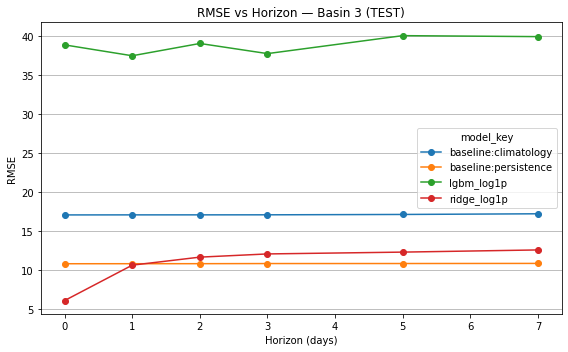

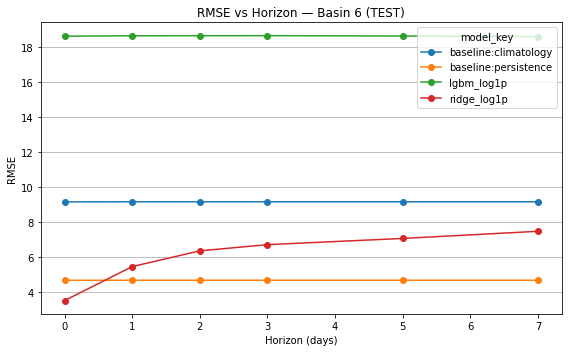

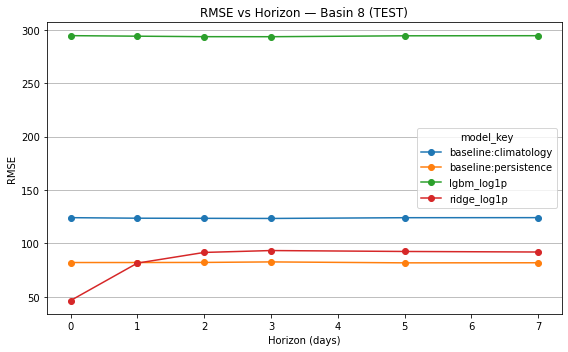

In [72]:
# keep just TEST split (change if you want "val" or both)
metrics_test = metrics_combined[metrics_combined["split"] == "test"]

# Filter to numeric basin_id only (drop "ALL" or other non-numeric)
metrics_test = metrics_test[
    pd.to_numeric(metrics_test["basin_id"], errors="coerce").notna()
].copy()

for b in sorted(metrics_test["basin_id"].unique()):
    sub = metrics_test[metrics_test["basin_id"] == b]
    pivot = (
        sub.pivot_table(index="horizon", columns="model_key", values="rmse", aggfunc="first")
           .sort_index()
    )
    ax = pivot.plot(marker="o", figsize=(8, 5))
    ax.set_title(f"RMSE vs Horizon — Basin {b} (TEST)")
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel("RMSE")
    ax.grid(True, axis="y")
    plt.tight_layout()
    plt.show()